In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from typing import List, Tuple
from torchinfo import summary

In [2]:
import matplotlib.patches as patches
import multiprocessing
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib
import pickle

# HeatMap 학습 코드

In [3]:
# ==========================================
# 1. 데이터 로드 및 통합 함수
# ==========================================
def load_and_merge_npy_files(npy_file_list):
    """
    여러 개의 .npy 파일 경로를 리스트로 받아 하나의 numpy 배열로 병합하는 함수
    추후 데이터가 추가되면 리스트에 경로만 추가하면 됨.
    """
    merged_data = []
    print("=== 데이터 로딩 시작 ===")
    for file_path in npy_file_list:
        if os.path.exists(file_path):
            data = np.load(file_path)
            merged_data.append(data)
            print(f"로딩 완료: {file_path} (Shape: {data.shape})")
        else:
            print(f"경고: 파일을 찾을 수 없습니다 - {file_path}")
            
    if not merged_data:
        raise ValueError("유효한 데이터가 로드되지 않았습니다.")
        
    # 첫 번째 차원(Batch)을 기준으로 병합
    final_data = np.concatenate(merged_data, axis=0)
    print(f"=== 총 통합 데이터 Shape: {final_data.shape} ===\n")
    final_data = np.ascontiguousarray(final_data, dtype=np.float32)
    
    return final_data

def _normalise(arr: np.ndarray, min_val: float, max_val: float) -> np.ndarray:
    normed = (arr - min_val) / (max_val - min_val + 1e-8)
    return np.clip(normed, 0.0, 1.0)


def _denormalise(arr: np.ndarray, min_val: float, max_val: float) -> np.ndarray:
    return arr * (max_val - min_val) + min_val

# 1. Base Class: 공통 데이터 로드 및 전처리 전담
class BaseDataset(Dataset):
    def __init__(self, sensor_data: np.ndarray, heatmap_data: np.ndarray, indices: List[int]):
        """
        indices 매개변수를 통해 Train/Val/Test 중 해당하는 인덱스만 접근하도록 강제하여
        Data Leakage를 원천적으로 차단합니다.
        """
        self.sensor_tensor = torch.from_numpy(sensor_data).float()
        # 정규화, 노이즈 필터링 코드
        self.min_val = np.min(heatmap_data)
        self.max_val = np.max(heatmap_data)
        norm_heat = _normalise(heatmap_data, self.min_val, self.max_val)
        norm_heat = np.expand_dims(norm_heat, axis=1)
        self.heatmap_tensor = torch.from_numpy(norm_heat).float()

        self.indices = indices

        # 데이터 길이 검증 (Sensor와 Heatmap의 페어 확인)
        assert len(self.sensor_tensor) == len(self.heatmap_tensor), "센서와 히트맵 데이터의 개수가 일치하지 않습니다."

    def __len__(self) -> int:
        return len(self.indices)
    
    def _load_sensor(self, real_idx: int) -> torch.Tensor:
        """
        실제 센서 데이터를 로드하고 전처리(예: 정규화, 노이즈 필터링)하는 로직.
        현재는 더미 텐서를 반환합니다.
        """
        # 정규화, 노이즈 필터링 코드
        return self.sensor_tensor[real_idx]

    def _load_heatmap(self, real_idx: int) -> torch.Tensor:
        """
        실제 30x30 온도 배열을 로드하고 전처리하는 로직.
        """
        return self.heatmap_tensor[real_idx]

# 2. Child Classes: Task별 모델 입출력 형태만 결정 (Overriding)
class CAEDataset(BaseDataset):
    """
    Model 1 (CAE) 학습용 Dataset.
    목적: Heatmap을 입력받아 Heatmap을 복원. 센서 데이터는 로드하지 않아 I/O 최적화.
    """
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        real_idx = self.indices[idx]
        heatmap = self._load_heatmap(real_idx)
        # Input == Target
        return heatmap, heatmap

class SensorLatentDataset(BaseDataset):
    """
    Model 2 (Sensor-to-Latent) 학습용 Dataset.
    목적: Sensor를 입력받아 최종 Heatmap Reconstruction Loss 계산을 위해 둘 다 로드.
    """
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        real_idx = self.indices[idx]
        sensor = self._load_sensor(real_idx)
        heatmap = self._load_heatmap(real_idx)
        # Input: Sensor, Target: Heatmap (Loss 계산용)
        return sensor, heatmap

In [4]:
def create_dataloader(sensor_paths: List[str], heatmap_paths: List[str], batch_size: int = 32):
    full_sensor_data = load_and_merge_npy_files(sensor_paths)
    full_heatmap_data = load_and_merge_npy_files(heatmap_paths)
    
    total_size = full_sensor_data.shape[0]
    all_indices = list(range(total_size))
    print(f"Total samples to split: {total_size}")

    # 1. Global Split (단 한 번만 수행하여 고정)
    # Train 70%, Val 15%, Test 15%
    train_idx, temp_idx = train_test_split(all_indices, test_size=0.3, random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

    # 2. Task별 인스턴스 생성 (동일한 인덱스 주입) 
    # Model 1 Dataset
    cae_train_ds = CAEDataset(full_sensor_data, full_heatmap_data, train_idx)
    cae_val_ds = CAEDataset(full_sensor_data, full_heatmap_data, val_idx)
    cae_test_ds = CAEDataset(full_sensor_data, full_heatmap_data, test_idx)

    # Model 2 Dataset
    sensor_train_ds = SensorLatentDataset(full_sensor_data, full_heatmap_data, train_idx)
    sensor_val_ds = SensorLatentDataset(full_sensor_data, full_heatmap_data, val_idx)
    sensor_test_ds = SensorLatentDataset(full_sensor_data, full_heatmap_data, test_idx)
    
    # 3. DataLoader 생성
    cae_train_loader = DataLoader(cae_train_ds, batch_size=batch_size, shuffle=True)
    cae_val_loader = DataLoader(cae_val_ds, batch_size=batch_size, shuffle=False)
    cae_test_loader = DataLoader(cae_test_ds, batch_size=batch_size, shuffle=False)

    sensor_train_loader = DataLoader(sensor_train_ds, batch_size=batch_size, shuffle=True)
    sensor_val_loader = DataLoader(sensor_val_ds, batch_size=batch_size, shuffle=False)
    sensor_test_loader = DataLoader(sensor_test_ds, batch_size=batch_size, shuffle=False)

    return (cae_train_loader, cae_val_loader, cae_test_loader), (sensor_train_loader, sensor_val_loader, sensor_test_loader)

In [5]:
# ==========================================
# 2-1. CNN Autoencoder 모델 정의
# ==========================================
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super(ConvAutoencoder, self).__init__()
        
        # Encoder
        # 입력: (Batch, 1, 30, 30)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2),
            # (16, 30, 30) -> stride=2 적용 시 (16, 15, 15)로 정확히 절반 축소
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2)
        )
        # 32 channels * 15 height * 15 width = 7200
        self.fc_enc = nn.Linear(32 * 15 * 15, latent_dim)
        
        # Decoder
        self.fc_dec = nn.Linear(latent_dim, 32 * 15 * 15)
        self.decoder = nn.Sequential(
            # output_padding=1 을 주어 (15, 15)에서 (30, 30)로 정확히 복원
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid() # 정규화된 0~1 값을 출력하기 위함
        )

    def forward(self, x):
        # Encoding
        x = self.encoder(x)
        x = x.view(x.size(0), -1) # Flatten
        latent = self.fc_enc(x)
        
        # Decoding
        x = self.fc_dec(latent)
        x = x.view(x.size(0), 32, 15, 15) # Reshape
        reconstructed = self.decoder(x)
        return reconstructed

In [6]:
# ==========================================
# 2-2. 메인 예측 모델 (Sensor -> Latent)
# ==========================================
class SensorToLatentModel(nn.Module):
    def __init__(self, in_channels=22, seq_len=5, latent_dim=16):
        super(SensorToLatentModel, self).__init__()
        # 1D CNN 입력 조건: (Batch, Channels, Sequence_Length)
        self.conv1d_layers = nn.Sequential(
            nn.Conv1d(in_channels=in_channels, out_channels=32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2)
        )
        # Flatten 후 크기: 64 channels * 5 seq_len = 320
        self.fc = nn.Sequential(
            nn.Linear(64 * seq_len, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, latent_dim)
        )

    def forward(self, x):
        # x shape: (Batch, 5, 22) -> (Batch, 22, 5) 변환 필요
        x = x.permute(0, 2, 1) 
        x = self.conv1d_layers(x)
        x = x.view(x.size(0), -1) # Flatten
        latent = self.fc(x)
        return latent

In [7]:
# ==========================================
# 2-3. End-to-End 통합 모델 (Main Model + Frozen Decoder)
# ==========================================
class EndToEndWeldingModel(nn.Module):
    def __init__(self, pretrained_ae, in_channels=4, seq_len=5, latent_dim=16):
        super(EndToEndWeldingModel, self).__init__()
        # 센서 데이터로 Latent 예측 (학습 대상)
        self.sensor_model = SensorToLatentModel(in_channels, seq_len, latent_dim)
        
        # 사전 학습된 Decoder 이식
        self.fc_dec = pretrained_ae.fc_dec
        self.decoder = pretrained_ae.decoder
        
        # Decoder 가중치 동결 (Freeze)
        for param in self.fc_dec.parameters():
            param.requires_grad = False
        for param in self.decoder.parameters():
            param.requires_grad = False

    def forward(self, x):
        # 1. 22차원 시계열 데이터 -> Latent Vector (14차원) 예측
        pred_latent = self.sensor_model(x)
        
        # 2. Latent Vector -> (14, 22) 히트맵 복원
        heatmap = self.fc_dec(pred_latent)
        heatmap = heatmap.view(heatmap.size(0), 32, 15, 15)
        pred_heatmap = self.decoder(heatmap)
        
        return pred_heatmap

In [8]:
# ==========================================
# 3. 학습 및 그래프 출력 함수
# ==========================================
def CAE_train(cae_loaders, latent_dim=16, epochs=50, lr=0.001, device='cuda'):
    model = ConvAutoencoder(latent_dim=latent_dim).to(device)
    criterion = nn.MSELoss() # 손실 함수 (MSE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
    
    train_loader, val_loader = cae_loaders[0], cae_loaders[1]

    for epoch in range(epochs):
        # -- Training --
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:    # [32, 1, 30, 30], [32, 1, 30, 30]
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            
        train_loss /= len(train_loader.dataset)

        # -- Validation --
        model.eval()
        val_loss = 0.0
        val_mae = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
                
                # MAE 계산 (픽셀 단위 오차 확인용)
                mae = torch.abs(outputs - inputs).mean()
                val_mae += mae.item() * inputs.size(0)
                
        val_loss /= len(val_loader.dataset)
        val_mae /= len(val_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)
        
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss(MSE): {train_loss:.6f} | Val Loss(MSE): {val_loss:.6f} | Val MAE: {val_mae:.6f}")
           
    # -- 학습 그래프 시각화 --
    plt.figure(figsize=(12, 4))
    
    # Loss 그래프 (MSE)
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss (MSE)')
    plt.plot(history['val_loss'], label='Val Loss (MSE)')
    plt.title('Autoencoder Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # "Accuracy" 대용 지표 그래프 (MAE)
    plt.subplot(1, 2, 2)
    plt.plot(history['val_mae'], label='Val MAE (Absolute Error)', color='green')
    plt.title('Validation Error (MAE)')
    plt.xlabel('Epochs')
    plt.ylabel('Error')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    return model, history

In [9]:
def Main_model_train(pretrained_ae_model, sensor_loaders, epochs=50, lr=0.001, device='cuda'):
   
    # 1. 통합 모델 초기화 (Decoder 동결 완료)
    model = EndToEndWeldingModel(pretrained_ae_model, latent_dim=16).to(device)

    train_loader, val_loader = sensor_loaders[0], sensor_loaders[1]
    
    criterion = nn.MSELoss()
    # 주의: Decoder는 동결되었으므로 SensorModel의 파라미터만 옵티마이저에 전달
    optimizer = optim.Adam(model.sensor_model.parameters(), lr=lr)
    
    print("=== 메인 모델(Sensor->Latent) 학습 시작 ===")
    history = {'train_loss': [], 'val_loss': [], 'val_mae': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            pred_heatmap = model(batch_x)
            loss = criterion(pred_heatmap, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_x.size(0)
            
        # Validation
        model.eval()
        val_loss = 0.0
        val_mae = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                pred_heatmap = model(batch_x)
                loss = criterion(pred_heatmap, batch_y)
                val_loss += loss.item() * batch_x.size(0)
                
                # MAE 계산 (픽셀 단위 오차 확인용)
                mae = torch.abs(pred_heatmap - batch_y).mean()
                val_mae += mae.item() * batch_y.size(0)
                
        train_loss /= len(train_loader.dataset)
        
        val_loss /= len(val_loader.dataset)
        val_mae /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)
        
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")

    # -- 학습 그래프 시각화 --
    plt.figure(figsize=(12, 4))
    
    # Loss 그래프 (MSE)
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss (MSE)')
    plt.plot(history['val_loss'], label='Val Loss (MSE)')
    plt.title('End-to-End Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # "Accuracy" 대용 지표 그래프 (MAE)
    plt.subplot(1, 2, 2)
    plt.plot(history['val_mae'], label='Val MAE (Absolute Error)', color='green')
    plt.title('Validation Error (MAE)')
    plt.xlabel('Epochs')
    plt.ylabel('Error')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    

    return model, history

In [10]:
def reconstruction_test(model, test_dataloader, num_samples=5):
    device = next(model.parameters()).device
    model.eval()
    
    # Test 데이터셋에서 무작위 샘플 추출
    test_dataset = test_dataloader.dataset
    
    # 데이터셋에서 물리적 온도 스케일(min, max) 추출
    min_val = getattr(test_dataloader.dataset, 'min_val', 0.0)
    max_val = getattr(test_dataloader.dataset, 'max_val', 1.0)
    print(min_val, max_val)
    
    indices = random.sample(range(len(test_dataset)), min(num_samples, len(test_dataset)))
    
    fig, axes = plt.subplots(len(indices), 2, figsize=(8, 3 * len(indices)))
    if len(indices) == 1:
        axes = [axes]
        
    with torch.no_grad():
        for i, idx in enumerate(indices):
            original_tensor, _ = test_dataset[idx]
            input_tensor = original_tensor.unsqueeze(0).to(device)
            
            reconstructed_tensor = model(input_tensor)
            
            # Numpy 변환 및 차원 축소
            original_img = original_tensor.squeeze().cpu().numpy()
            reconstructed_img = reconstructed_tensor.squeeze().cpu().numpy()
            
            # 정규화 역산 (실제 물리량 복원)
            original_real = original_img * (max_val - min_val) + min_val
            reconstructed_real = reconstructed_img * (max_val - min_val) + min_val
            
            # 시각화
            im1 = axes[i][0].imshow(original_real, cmap='inferno', origin='upper')
            axes[i][0].set_title(f'Test Sample {idx}: Original')
            axes[i][0].axis('off')
            fig.colorbar(im1, ax=axes[i][0], fraction=0.046, pad=0.04)
            
            im2 = axes[i][1].imshow(reconstructed_real, cmap='inferno', origin='upper')
            axes[i][1].set_title(f'Test Sample {idx}: Reconstructed')
            axes[i][1].axis('off')
            fig.colorbar(im2, ax=axes[i][1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

In [11]:
def EndtoEnd_test_Evaluation(model, test_dataloader, num_samples=5):
    device = next(model.parameters()).device
    model.eval()
    
    # Test 데이터셋에서 무작위 샘플 추출
    test_dataset = test_dataloader.dataset
    
    # 데이터셋에서 물리적 온도 스케일(min, max) 추출
    min_val = getattr(test_dataloader.dataset, 'min_val', 0.0)
    max_val = getattr(test_dataloader.dataset, 'max_val', 1.0)
    print(min_val, max_val)
    
    indices = random.sample(range(len(test_dataset)), min(num_samples, len(test_dataset)))
    
    fig, axes = plt.subplots(len(indices), 2, figsize=(8, 3 * len(indices)))
    if len(indices) == 1:
        axes = [axes]
        
    with torch.no_grad():
        for i, idx in enumerate(indices):
            sensor_tensor, original_tensor = test_dataset[idx] # sensor, heatmap
            input_tensor = sensor_tensor.unsqueeze(0).to(device)
            
            reconstructed_tensor = model(input_tensor)
            
            # Numpy 변환 및 차원 축소
            original_img = original_tensor.squeeze().cpu().numpy()
            reconstructed_img = reconstructed_tensor.squeeze().cpu().numpy()
            
            # 정규화 역산 (실제 물리량 복원)
            original_real = original_img * (max_val - min_val) + min_val
            reconstructed_real = reconstructed_img * (max_val - min_val) + min_val
            
            # 시각화
            im1 = axes[i][0].imshow(original_real, cmap='inferno', origin='upper')
            axes[i][0].set_title(f'Test Sample {idx}: Original')
            axes[i][0].axis('off')
            fig.colorbar(im1, ax=axes[i][0], fraction=0.046, pad=0.04)
            
            im2 = axes[i][1].imshow(reconstructed_real, cmap='inferno', origin='upper')
            axes[i][1].set_title(f'Test Sample {idx}: Reconstructed')
            axes[i][1].axis('off')
            fig.colorbar(im2, ax=axes[i][1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

In [12]:
# ==========================================
# 실행 예시 (추후 데이터 추가 시 리스트에 경로만 추가하면 됨)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_dir = os.getcwd()
dataset_dir = os.path.join(base_dir, 'dataset')

idx_st = 31
idx_end = 61

# TF033 ~ TF060 자동 생성
heatmap_files = [
    os.path.join(dataset_dir, f"aligned_heatmap_TF{i:03d}.npy")
    for i in range(idx_st, idx_end)
]

sensor_files = [
    os.path.join(dataset_dir, f"window_sensors_TF{i:03d}.npy")
    for i in range(idx_st, idx_end)
]

cae_loaders, sensor_loaders = create_dataloader(sensor_files, heatmap_files)

Using device: cuda
=== 데이터 로딩 시작 ===
로딩 완료: c:\Users\82104\Desktop\weld-pool-prediction\notebooks\seonyang\dataset\window_sensors_TF031.npy (Shape: (1855, 5, 4))
로딩 완료: c:\Users\82104\Desktop\weld-pool-prediction\notebooks\seonyang\dataset\window_sensors_TF032.npy (Shape: (1428, 5, 4))
로딩 완료: c:\Users\82104\Desktop\weld-pool-prediction\notebooks\seonyang\dataset\window_sensors_TF033.npy (Shape: (1445, 5, 4))
로딩 완료: c:\Users\82104\Desktop\weld-pool-prediction\notebooks\seonyang\dataset\window_sensors_TF034.npy (Shape: (1538, 5, 4))
로딩 완료: c:\Users\82104\Desktop\weld-pool-prediction\notebooks\seonyang\dataset\window_sensors_TF035.npy (Shape: (1305, 5, 4))
로딩 완료: c:\Users\82104\Desktop\weld-pool-prediction\notebooks\seonyang\dataset\window_sensors_TF036.npy (Shape: (1156, 5, 4))
로딩 완료: c:\Users\82104\Desktop\weld-pool-prediction\notebooks\seonyang\dataset\window_sensors_TF037.npy (Shape: (2323, 5, 4))
로딩 완료: c:\Users\82104\Desktop\weld-pool-prediction\notebooks\seonyang\dataset\window_sen

In [13]:
cae_loaders[0].dataset.heatmap_tensor[20000, 0]

tensor([[0.2486, 0.2187, 0.1869, 0.1835, 0.1894, 0.1943, 0.1877, 0.1825, 0.1847,
         0.1871, 0.1885, 0.1810, 0.1739, 0.1708, 0.1670, 0.1655, 0.1627, 0.1595,
         0.1543, 0.1487, 0.1436, 0.1382, 0.1330, 0.1289, 0.1236, 0.1225, 0.1215,
         0.1125, 0.1116, 0.1120],
        [0.2057, 0.1863, 0.1818, 0.1924, 0.2005, 0.2106, 0.2059, 0.1968, 0.1973,
         0.1966, 0.1947, 0.1918, 0.1869, 0.1830, 0.1789, 0.1782, 0.1735, 0.1667,
         0.1618, 0.1552, 0.1510, 0.1462, 0.1398, 0.1344, 0.1265, 0.1247, 0.1252,
         0.1202, 0.1165, 0.1149],
        [0.1916, 0.1797, 0.1894, 0.2037, 0.2182, 0.2320, 0.2333, 0.2179, 0.2081,
         0.2062, 0.2051, 0.2026, 0.1996, 0.1957, 0.1932, 0.1929, 0.1863, 0.1785,
         0.1716, 0.1645, 0.1602, 0.1552, 0.1501, 0.1433, 0.1332, 0.1313, 0.1296,
         0.1265, 0.1213, 0.1193],
        [0.2015, 0.1899, 0.2001, 0.2182, 0.2378, 0.2558, 0.2650, 0.2464, 0.2271,
         0.2232, 0.2210, 0.2189, 0.2165, 0.2129, 0.2104, 0.2095, 0.2032, 0.1952,
       

## autoencoder training

In [14]:
# trained_ae_model, cae_history = CAE_train(
#     cae_loaders=cae_loaders,
#     latent_dim=16, 
#     epochs=50, 
#     device=device
# )

# print("\n=== 학습 완료! Test 데이터셋 추론 시각화 진행 ===")

# # 4. Test 데이터셋(학습에 사용되지 않은 데이터) 추론 및 시각화
# test_loader = cae_loaders[2]
# reconstruction_test(trained_ae_model, test_loader, num_samples=5)

# 모델 저장
# torch.save(trained_ae_model.state_dict(), "heatmap_AE.pth")

=== TF040 데이터 로드 중 ===
총 1428개의 TF040 샘플 로드 완료.

=== TF040 모델 추론 시작 ===
Batch [10/23] 처리 완료...
Batch [20/23] 처리 완료...
=== 추론 완료! ===
예측된 TF040 용융풀 형태: (1428, 30, 30)
-8.25 3.116e+03


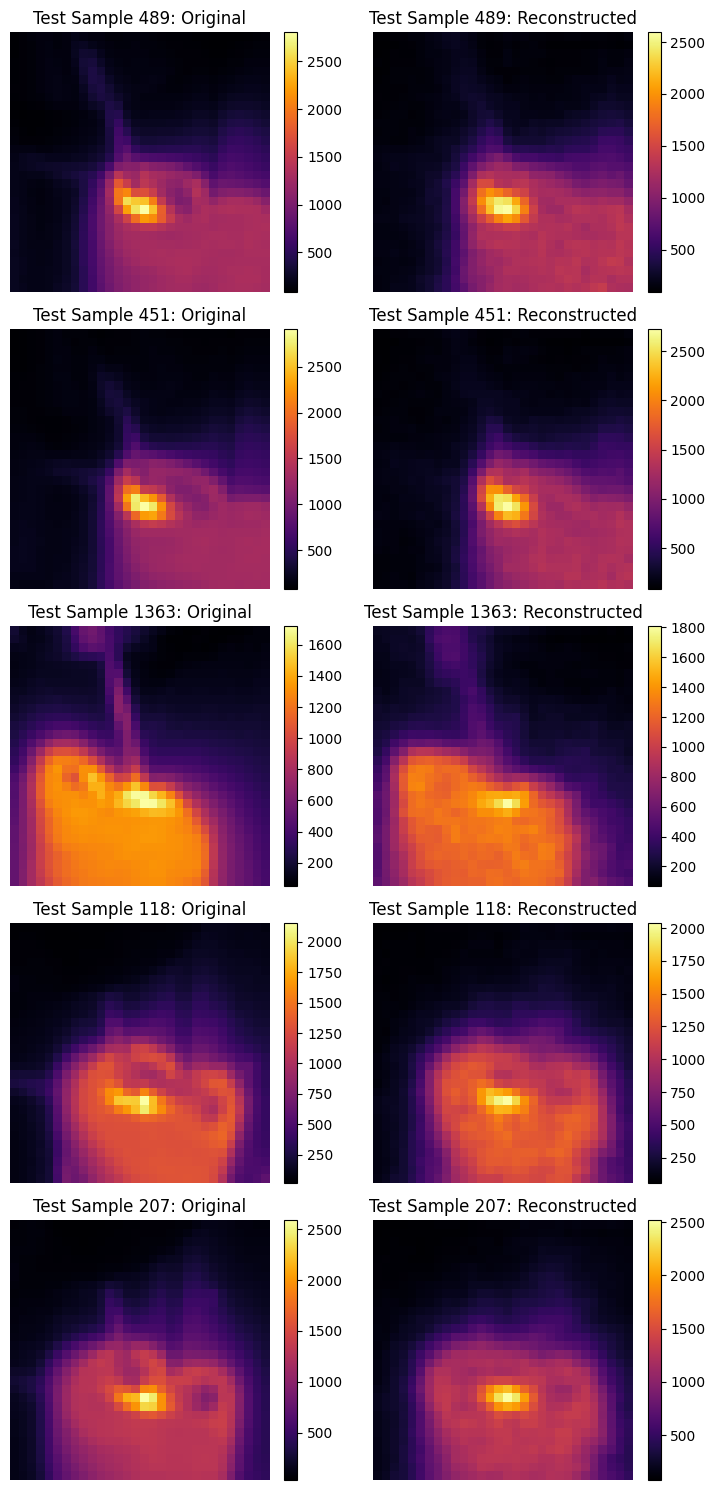

In [14]:
%matplotlib inline
# ==========================================
# 1. TF040 추론용 DataLoader 준비
# ==========================================
def prepare_inference_dataloader(tf040_sensor_path, tf040_heatmap_path, batch_size=64):
    """
    학습된 모델을 검증하기 위해 새로운 TF040 데이터를 로드합니다.
    """
    print("=== TF040 데이터 로드 중 ===")
    sensor_data = np.load(tf040_sensor_path)
    heatmap_data = np.load(tf040_heatmap_path)
    
    total_samples = heatmap_data.shape[0]
    indices = list(range(total_samples)) # Split 없이 전체 데이터를 사용
    
    # 이전에 최적화한 인메모리(In-Memory) Dataset 재사용
    inference_dataset = CAEDataset(sensor_data, heatmap_data, indices)
    
    # 추론 시에는 데이터를 섞을 필요가 없으므로 shuffle=False
    # RAM에 이미 올라가 있으므로 num_workers=0 유지
    inference_loader = DataLoader(inference_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"총 {total_samples}개의 TF040 샘플 로드 완료.")
    return inference_loader

# ==========================================
# 2. 추론 및 물리적 온도 변환 수행
# ==========================================
def run_inference_on_new_data(model, inference_loader, min_val, max_val, device='cuda'):
    """
    새로운 센서 데이터로 용융풀 온도를 추론하고, 결과를 물리적 스케일로 역정규화합니다.
    """
    model.eval() # 반드시 Eval 모드로 전환 (BatchNorm, Dropout 고정)
    model = model.to(device)
    
    all_predicted_real = []
    all_ground_truth_real = []
    
    print("\n=== TF040 모델 추론 시작 ===")
    with torch.no_grad(): # 역전파 메모리 낭비 방지
        for batch_idx, (x_batch, y_batch) in enumerate(inference_loader):
            x_batch = x_batch.to(device)
            
            # 모델 추론 (Sensor -> Latent -> Frozen Decoder -> Predicted Heatmap)
            pred_y_batch = model(x_batch)
            
            # GPU 텐서를 CPU로 내리고 Numpy 배열로 변환
            pred_numpy = pred_y_batch.squeeze().cpu().numpy()
            gt_numpy = y_batch.squeeze().cpu().numpy()
            
            # _denormalise 함수를 사용해 즉시 실제 온도로 변환
            pred_real = _denormalise(pred_numpy, min_val, max_val)
            gt_real = _denormalise(gt_numpy, min_val, max_val)
            
            all_predicted_real.append(pred_real)
            all_ground_truth_real.append(gt_real)
            
            if (batch_idx + 1) % 10 == 0:
                print(f"Batch [{batch_idx + 1}/{len(inference_loader)}] 처리 완료...")
                
    # 배치 단위로 나뉘어 있던 배열들을 하나의 거대한 시계열 배열로 병합
    final_predictions = np.concatenate(all_predicted_real, axis=0)
    final_ground_truths = np.concatenate(all_ground_truth_real, axis=0)
    
    print("=== 추론 완료! ===")
    print(f"예측된 TF040 용융풀 형태: {final_predictions.shape}")
    
    return final_predictions, final_ground_truths

# ==========================================
# 3. 실행 예시
# ==========================================
if __name__ == "__main__":
    # TF040 파일 경로 지정
    TF_case = "TF032"
    tf040_sensor_file = os.path.join(dataset_dir, f"window_sensors_{TF_case}.npy")
    tf040_heatmap_file = os.path.join(dataset_dir, f"aligned_heatmap_{TF_case}.npy")

    # 정규화에 사용되었던 글로벌 최소/최대값 (학습 시 사용한 값과 동일해야 함)
    GLOBAL_MIN_TEMP = sensor_loaders[0].dataset.min_val
    GLOBAL_MAX_TEMP = sensor_loaders[0].dataset.max_val
    
    trained_ae_model = ConvAutoencoder(latent_dim=16)
    trained_ae_model.load_state_dict(torch.load("heatmap_AE.pth"))
    trained_ae_model.to(device)

    # 1. 로더 생성
    tf040_loader = prepare_inference_dataloader(tf040_sensor_file, tf040_heatmap_file)
    
    # 2. 추론 수행 (final_model은 Step 2에서 학습이 끝난 모델)
    pred_heatmap, gt_tf040 = run_inference_on_new_data(trained_ae_model, tf040_loader, GLOBAL_MIN_TEMP, GLOBAL_MAX_TEMP)
    
    # 3. 예측 결과를 .npy로 저장 (후속 분석 용도)
    np.save("TF040_predicted_heatmaps.npy", pred_heatmap)
    # print("예측 결과가 'TF040_predicted_heatmaps.npy'로 저장되었습니다.")
    
    # 4. (선택) 우리가 만든 시각화 함수로 결과 직접 
    # EndtoEnd_test_Evaluation(trained_ae_model, tf040_loader, num_samples=5, track_frames=150)
    reconstruction_test(trained_ae_model, tf040_loader, num_samples=5)

In [ ]:
# matplotlib.use('Agg')  # GUI 없는 백엔드 (스레드 안전)

# # ---- 설정 ----
# output_dir = "frame_images_with_reconstruction_32"
# os.makedirs(output_dir, exist_ok=True)

# NUM_WORKERS = max(1, multiprocessing.cpu_count() - 1)

# # TODO: 실제 데이터 변수명에 맞게 수정하세요.
# # data: {프레임키: 2D 온도배열} 형태의 딕셔너리
# # keys: 프레임 키 리스트
# # predicted_heatmaps: 이전 단계에서 추론한 예측 온도 배열 (Shape: [N, 30, 30])
# # 주의: predicted_heatmaps의 0번 인덱스가 start_frame과 일치한다고 가정합니다.

# data_path = "../../data/raw/T-Fillet/TF031_060"
# TF_case = "TF032"
# TF_Pass = f"{TF_case}_1PASS"
# pkl_path = f"{data_path}/{TF_case}/{TF_Pass}/{TF_case}_FLIR.pkl"
# with open(pkl_path, "rb") as f:
#     data = pickle.load(f)


# data_ori = []
# crops = []
# indices = []  # (frame_index, key) 튜플 리스트

# for frame_index, (key, frame) in enumerate(data.items()):
#     if np.max(frame) < 800:
#         continue
#     h, w = frame.shape

#     # 최고 온도 픽셀 좌표
#     max_y, max_x = np.unravel_index(np.argmax(frame), frame.shape)

#     # 크롭 경계 계산
#     y1 = max_y - 30 // 2 - 5
#     y2 = max_y + 30 // 2 - 5
#     x1 = max_x - 30 // 2
#     x2 = max_x + 30 // 2

#     # 가장자리 보정
#     if y1 < 0:
#         y2 -= y1;  y1 = 0
#     if y2 > h:
#         y1 -= (y2 - h);  y2 = h
#     if x1 < 0:
#         x2 -= x1;  x1 = 0
#     if x2 > w:
#         x1 -= (x2 - w);  x2 = w

#     data_ori.append(frame)
#     crops.append(frame[y1:y2, x1:x2])
#     indices.append((frame_index, key))
    
# GLOBAL_MIN_TEMP = sensor_loaders[0].dataset.min_val
# GLOBAL_MAX_TEMP = sensor_loaders[0].dataset.max_val

# # 전체 온도 범위 (GT 데이터 기준)
# # global_min = min(np.min(f) for f in data.values())
# # global_max = max(np.max(f) for f in data.values())

# print(f"온도 범위: {GLOBAL_MIN_TEMP:.1f} ~ {GLOBAL_MAX_TEMP:.1f}")
# print(f"저장 프레임: {0}~{len(pred_heatmap)-1} | workers: {NUM_WORKERS}")



# def process_frame(args):
#     # args에 예측된 히트맵(pred_heatmap)이 추가되었습니다.
#     idx, frame, pred_heatmap = args

#     # GT 프레임 기준 최대 온도 지점 탐색
#     max_y, max_x = np.unravel_index(np.argmax(frame), frame.shape)
#     max_temp = frame[max_y, max_x]

#     # 30x30 ROI 바운딩 박스 계산
#     y1 = max_y - 20; y2 = max_y + 10
#     x1 = max_x - 15; x2 = max_x + 15
#     H, W = frame.shape
#     if y1 < 0:   y2 -= y1;        y1 = 0
#     if y2 > H:   y1 -= (y2 - H);  y2 = H
#     if x1 < 0:   x2 -= x1;        x1 = 0
#     if x2 > W:   x1 -= (x2 - W);  x2 = W

#     cropped = frame[y1:y2, x1:x2]
#     rel_y = max_y - y1 - 5
#     rel_x = max_x - x1

#     # 컬러맵 설정 (GT와 예측 결과 모두 동일한 스케일 적용)
#     vkw = dict(cmap='inferno', vmin=GLOBAL_MIN_TEMP, vmax=GLOBAL_MAX_TEMP)

#     # 1x3 서브플롯으로 확장 (가로 폭을 10 -> 14로 늘림)
#     fig, axes = plt.subplots(1, 3, figsize=(14, 4),
#                              gridspec_kw={'wspace': 0.05})

#     # 1. 원본 열화상 프레임 + ROI 박스
#     ax1 = axes[0]
#     ax1.imshow(frame, **vkw, aspect='auto')
#     ax1.add_patch(patches.Rectangle(
#         (x1, y1), x2-x1, y2-y1,
#         linewidth=1.2, edgecolor='cyan', facecolor='none'))
#     ax1.scatter([max_x], [max_y], c='red', marker='x', s=60, linewidths=1)
#     ax1.set_title(f"#{idx}  {max_temp:.0f}°C", fontsize=8, pad=2)
#     ax1.axis('off')

#     # 2. 정답(GT) ROI Crop
#     ax2 = axes[1]
#     im = ax2.imshow(cropped, **vkw, aspect='auto')
#     ax2.scatter([rel_x], [rel_y], c='red', marker='x', s=60, linewidths=1)
#     ax2.set_title("GT Crop (30x30)", fontsize=8, pad=2)
#     ax2.axis('off')

#     # 3. 모델 예측(Predicted) 히트맵
#     ax3 = axes[2]
#     # 예측된 히트맵을 시각화합니다.
#     ax3.imshow(pred_heatmap, **vkw, aspect='auto')
#     ax3.set_title("Predicted ROI (30x30)", fontsize=8, pad=2)
#     ax3.axis('off')

#     # 컬러바 설정 (axes 배열 전체를 대상으로 하여 우측에 하나만 생성)
#     cb = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.02)
#     cb.ax.tick_params(labelsize=6)
#     cb.set_label('°C', fontsize=7)

#     fig.suptitle(f"Frame {idx}", fontsize=10, y=0.98)

#     save_path = os.path.join(output_dir, f"f{idx:04d}.jpg")
#     fig.savefig(save_path, dpi=80, format='jpeg',
#                 bbox_inches='tight',
#                 pil_kwargs={'quality': 75, 'optimize': True})
#     plt.close(fig)
#     return idx

# # ---- 실행 ----
# # 인덱스 매칭 방식을 정의합니다. 
# # 만약 예측 히트맵 배열(predicted_heatmaps)이 start_frame부터 시작되도록
# # 정렬되어 있다면 아래와 같이 매핑합니다.
# args_list = [
#     (
#         idx, 
#         data_ori[idx], 
#         pred_heatmap[idx] # 예측 배열 인덱스 동기화 핵심
#     )
#     for idx in range(0, len(pred_heatmap))
# ]

# done = 0
# total = len(args_list)

# with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
#     futures = {executor.submit(process_frame, a): a[0] for a in args_list}
#     for future in as_completed(futures):
#         try:
#             future.result()
#         except Exception as e:
#             print(f"  ⚠️ 오류: {e}")
#         done += 1
#         if done % 200 == 0 or done == total:
#             print(f"  {done}/{total} ({done/total*100:.1f}%)")


# print(f"\n✅ 완료 → {output_dir}/  ({total}장)")

온도 범위: -34.7 ~ 3160.0
저장 프레임: 0~1427 | workers: 15
  200/1428 (14.0%)
  400/1428 (28.0%)
  600/1428 (42.0%)
  800/1428 (56.0%)
  1000/1428 (70.0%)
  1200/1428 (84.0%)
  1400/1428 (98.0%)
  1428/1428 (100.0%)

✅ 완료 → frame_images_with_reconstruction_32/  (1428장)


In [22]:
print(sensor_loaders[0].dataset.min_val)
print(sensor_loaders[0].dataset.max_val)

-34.65625
3160.0


## Main model training

In [23]:
# # 3. 메인 파이프라인 학습 실행
# final_model, main_history = Main_model_train(
#     pretrained_ae_model=trained_ae_model, 
#     sensor_loaders=sensor_loaders, 
#     epochs=50, 
#     lr=0.001,
#     device=device)
# 모델 저장
# torch.save(final_model.state_dict(), "final_model.pth")
# 노트북에서: 학습 후 min/max 저장
np.save("heatmap_scale.npy", np.array([
    sensor_loaders[0].dataset.min_val,
    sensor_loaders[0].dataset.max_val
]))


=== 학습 완료! Test 데이터셋 추론 시각화 진행 ===
-34.65625 3160.0


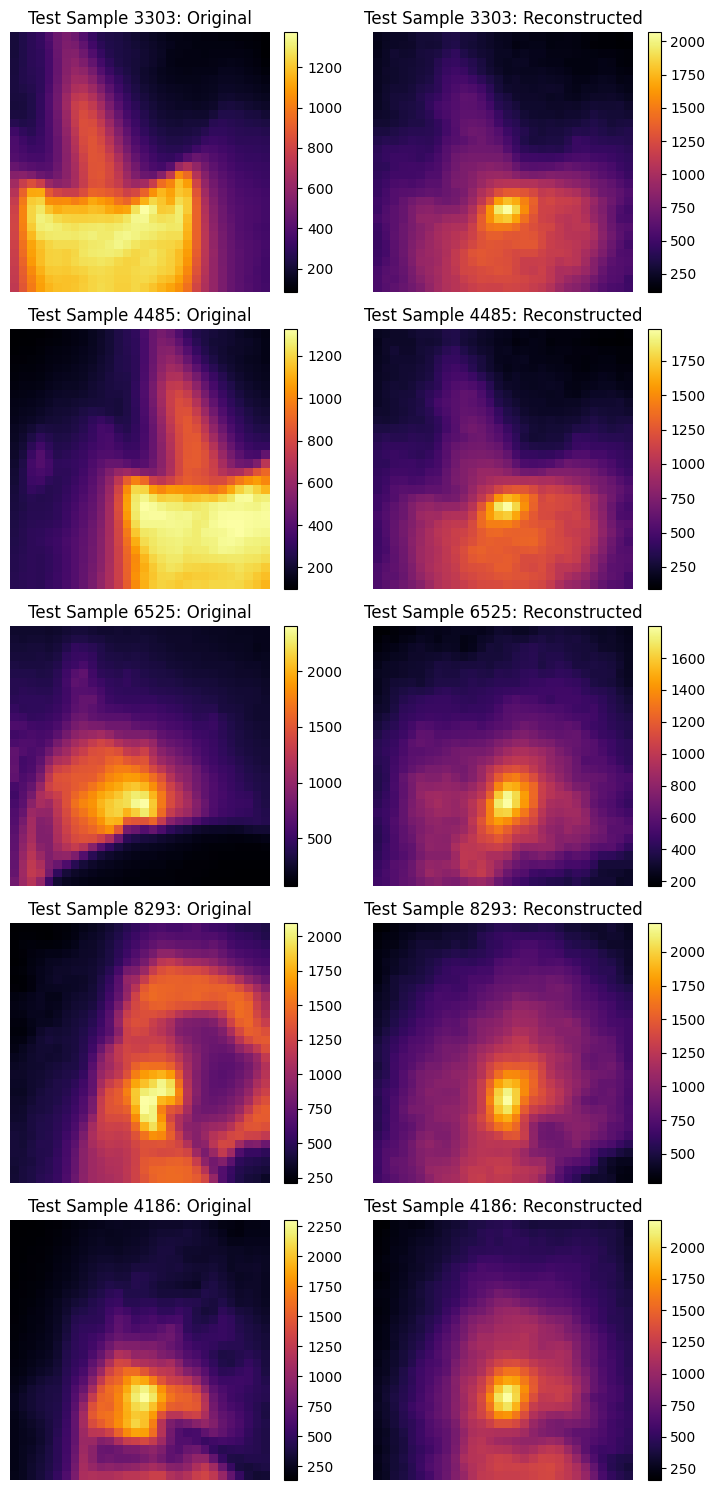

In [15]:

final_model = EndToEndWeldingModel(trained_ae_model, in_channels=4, seq_len=5, latent_dim=16)
final_model.load_state_dict(torch.load("final_model.pth"))
final_model.to(device)
print("\n=== 학습 완료! Test 데이터셋 추론 시각화 진행 ===")
    
test_dataloader = sensor_loaders[2] # 구축하신 DataLoader 리스트에서 Test 로더 추출
EndtoEnd_test_Evaluation(final_model, test_dataloader, num_samples=5)

In [17]:
getattr(test_dataloader, 'max_temp')

AttributeError: 'DataLoader' object has no attribute 'max_temp'

=== TF040 데이터 로드 중 ===
총 1307개의 TF040 샘플 로드 완료.

=== TF040 모델 추론 시작 ===
Batch [10/21] 처리 완료...
Batch [20/21] 처리 완료...
=== 추론 완료! ===
예측된 TF040 용융풀 형태: (1307, 30, 30)
11.72 3.006e+03


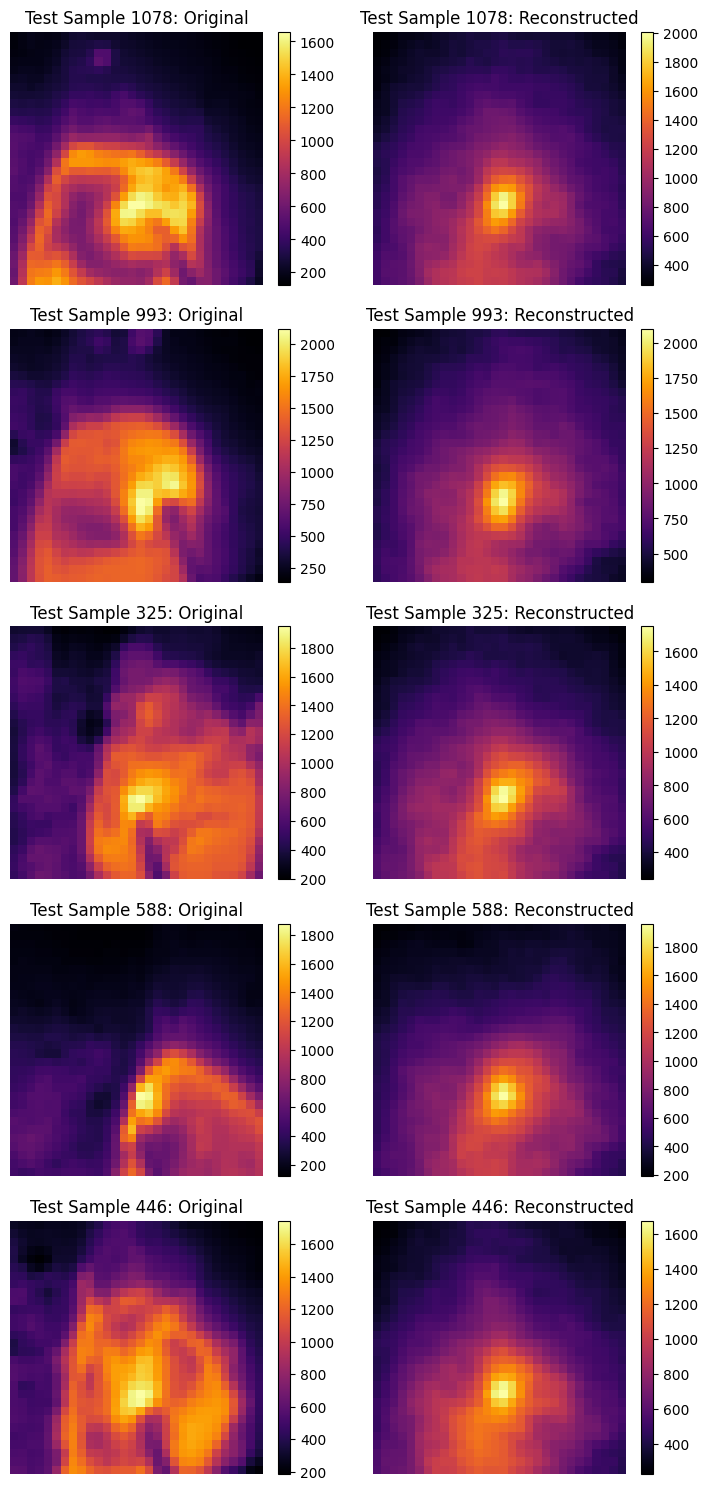

In [19]:
%matplotlib inline

import torch
import numpy as np
from torch.utils.data import DataLoader

# ==========================================
# 1. TF040 추론용 DataLoader 준비
# ==========================================
def prepare_inference_dataloader(tf040_sensor_path, tf040_heatmap_path, batch_size=64):
    """
    학습된 모델을 검증하기 위해 새로운 TF040 데이터를 로드합니다.
    """
    print(f"=== {TF_case} 데이터 로드 중 ===")
    sensor_data = np.load(tf040_sensor_path)
    heatmap_data = np.load(tf040_heatmap_path)
    
    total_samples = sensor_data.shape[0]
    indices = list(range(total_samples)) # Split 없이 전체 데이터를 사용
    
    # 이전에 최적화한 인메모리(In-Memory) Dataset 재사용
    inference_dataset = SensorLatentDataset(sensor_data, heatmap_data, indices)
    
    # 추론 시에는 데이터를 섞을 필요가 없으므로 shuffle=False
    # RAM에 이미 올라가 있으므로 num_workers=0 유지
    inference_loader = DataLoader(inference_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"총 {total_samples}개의 {TF_case} 샘플 로드 완료.")
    return inference_loader

# ==========================================
# 2. 추론 및 물리적 온도 변환 수행
# ==========================================
def run_inference_on_new_data(model, inference_loader, min_val, max_val, device='cuda'):
    """
    새로운 센서 데이터로 용융풀 온도를 추론하고, 결과를 물리적 스케일로 역정규화합니다.
    """
    model.eval() # 반드시 Eval 모드로 전환 (BatchNorm, Dropout 고정)
    model = model.to(device)
    
    all_predicted_real = []
    all_ground_truth_real = []
    
    print("\n=== TF040 모델 추론 시작 ===")
    with torch.no_grad(): # 역전파 메모리 낭비 방지
        for batch_idx, (x_batch, y_batch) in enumerate(inference_loader):
            x_batch = x_batch.to(device)
            
            # 모델 추론 (Sensor -> Latent -> Frozen Decoder -> Predicted Heatmap)
            pred_y_batch = model(x_batch)
            
            # GPU 텐서를 CPU로 내리고 Numpy 배열로 변환
            pred_numpy = pred_y_batch.squeeze().cpu().numpy()
            gt_numpy = y_batch.squeeze().cpu().numpy()
            
            # _denormalise 함수를 사용해 즉시 실제 온도로 변환
            pred_real = _denormalise(pred_numpy, min_val, max_val)
            gt_real = _denormalise(gt_numpy, min_val, max_val)
            
            all_predicted_real.append(pred_real)
            all_ground_truth_real.append(gt_real)
            
            if (batch_idx + 1) % 10 == 0:
                print(f"Batch [{batch_idx + 1}/{len(inference_loader)}] 처리 완료...")
                
    # 배치 단위로 나뉘어 있던 배열들을 하나의 거대한 시계열 배열로 병합
    final_predictions = np.concatenate(all_predicted_real, axis=0)
    final_ground_truths = np.concatenate(all_ground_truth_real, axis=0)
    
    print("=== 추론 완료! ===")
    print(f"예측된 TF040 용융풀 형태: {final_predictions.shape}")
    
    return final_predictions, final_ground_truths

# ==========================================
# 3. 실행 예시
# ==========================================
if __name__ == "__main__":
    
    # TF040 파일 경로 지정
    tf040_sensor_file = os.path.join(dataset_dir, f"window_sensors_{TF_case}.npy")
    tf040_heatmap_file = os.path.join(dataset_dir, f"aligned_heatmap_{TF_case}.npy")

    # 정규화에 사용되었던 글로벌 최소/최대값 (학습 시 사용한 값과 동일해야 함)
    GLOBAL_MIN_TEMP = sensor_loaders[0].dataset.min_val
    GLOBAL_MAX_TEMP = sensor_loaders[0].dataset.max_val
    
    # 1. 로더 생성
    tf040_loader = prepare_inference_dataloader(tf040_sensor_file, tf040_heatmap_file)
    
    # 2. 추론 수행 (final_model은 Step 2에서 학습이 끝난 모델)
    pred_heatmap, gt_tf040 = run_inference_on_new_data(final_model, tf040_loader, GLOBAL_MIN_TEMP, GLOBAL_MAX_TEMP)
    
    # 3. 예측 결과를 .npy로 저장 (후속 분석 용도)
    # np.save("TF040_predicted_heatmaps.npy", pred_heatmap)
    # print("예측 결과가 'TF040_predicted_heatmaps.npy'로 저장되었습니다.")
    
    # 4. (선택) 우리가 만든 시각화 함수로 결과 직접 
    EndtoEnd_test_Evaluation(final_model, tf040_loader, num_samples=5)
    # evaluate_and_visualize_performance(final_model, tf040_loader, dummy_history, num_samples=3)

In [ ]:
# matplotlib.use('Agg')  # GUI 없는 백엔드 (스레드 안전)

# # ---- 설정 ----
# output_dir = "frame_images_with_pred"
# os.makedirs(output_dir, exist_ok=True)

# NUM_WORKERS = max(1, multiprocessing.cpu_count() - 1)

# # TODO: 실제 데이터 변수명에 맞게 수정하세요.
# # data: {프레임키: 2D 온도배열} 형태의 딕셔너리
# # keys: 프레임 키 리스트
# # predicted_heatmaps: 이전 단계에서 추론한 예측 온도 배열 (Shape: [N, 30, 30])
# # 주의: predicted_heatmaps의 0번 인덱스가 start_frame과 일치한다고 가정합니다.

# data_path = "../../data/raw/T-Fillet/TF031_060"
# TF_Pass = f"{TF_case}_1PASS"
# pkl_path = f"{data_path}/{TF_case}/{TF_Pass}/{TF_case}_FLIR.pkl"

# with open(pkl_path, "rb") as f:
#     data = pickle.load(f)

# print(f"--- {TF_case} 데이터 전체 비교 ---")
# data_ori = []
# crops = []
# indices = []  # (frame_index, key) 튜플 리스트

# for frame_index, (key, frame) in enumerate(data.items()):
#     if np.max(frame) < 800:
#         continue
#     h, w = frame.shape

#     # 최고 온도 픽셀 좌표
#     max_y, max_x = np.unravel_index(np.argmax(frame), frame.shape)

#     # 크롭 경계 계산
#     y1 = max_y - 30 // 2 - 5
#     y2 = max_y + 30 // 2 - 5
#     x1 = max_x - 30 // 2
#     x2 = max_x + 30 // 2

#     # 가장자리 보정
#     if y1 < 0:
#         y2 -= y1;  y1 = 0
#     if y2 > h:
#         y1 -= (y2 - h);  y2 = h
#     if x1 < 0:
#         x2 -= x1;  x1 = 0
#     if x2 > w:
#         x1 -= (x2 - w);  x2 = w

#     data_ori.append(frame)
#     crops.append(frame[y1:y2, x1:x2])
#     indices.append((frame_index, key))
    
# GLOBAL_MIN_TEMP = sensor_loaders[0].dataset.min_val
# GLOBAL_MAX_TEMP = sensor_loaders[0].dataset.max_val

# # 전체 온도 범위 (GT 데이터 기준)
# # global_min = min(np.min(f) for f in data.values())
# # global_max = max(np.max(f) for f in data.values())

# print(f"온도 범위: {GLOBAL_MIN_TEMP:.1f} ~ {GLOBAL_MAX_TEMP:.1f}")
# print(f"저장 프레임: {0}~{len(pred_heatmap)-1} | workers: {NUM_WORKERS}")



# def process_frame(args):
#     # args에 예측된 히트맵(pred_heatmap)이 추가되었습니다.
#     idx, frame, pred_heatmap = args

#     # GT 프레임 기준 최대 온도 지점 탐색
#     max_y, max_x = np.unravel_index(np.argmax(frame), frame.shape)
#     max_temp = frame[max_y, max_x]

#     # 30x30 ROI 바운딩 박스 계산
#     y1 = max_y - 20; y2 = max_y + 10
#     x1 = max_x - 15; x2 = max_x + 15
#     H, W = frame.shape
#     if y1 < 0:   y2 -= y1;        y1 = 0
#     if y2 > H:   y1 -= (y2 - H);  y2 = H
#     if x1 < 0:   x2 -= x1;        x1 = 0
#     if x2 > W:   x1 -= (x2 - W);  x2 = W

#     cropped = frame[y1:y2, x1:x2]
#     rel_y = max_y - y1 - 5
#     rel_x = max_x - x1

#     # 컬러맵 설정 (GT와 예측 결과 모두 동일한 스케일 적용)
#     vkw = dict(cmap='inferno', vmin=GLOBAL_MIN_TEMP, vmax=GLOBAL_MAX_TEMP)

#     # 1x3 서브플롯으로 확장 (가로 폭을 10 -> 14로 늘림)
#     fig, axes = plt.subplots(1, 3, figsize=(14, 4),
#                              gridspec_kw={'wspace': 0.05})

#     # 1. 원본 열화상 프레임 + ROI 박스
#     ax1 = axes[0]
#     ax1.imshow(frame, **vkw, aspect='auto')
#     ax1.add_patch(patches.Rectangle(
#         (x1, y1), x2-x1, y2-y1,
#         linewidth=1.2, edgecolor='cyan', facecolor='none'))
#     ax1.scatter([max_x], [max_y], c='red', marker='x', s=60, linewidths=1)
#     ax1.set_title(f"#{idx}  {max_temp:.0f}°C", fontsize=8, pad=2)
#     ax1.axis('off')

#     # 2. 정답(GT) ROI Crop
#     ax2 = axes[1]
#     im = ax2.imshow(cropped, **vkw, aspect='auto')
#     ax2.scatter([rel_x], [rel_y], c='red', marker='x', s=60, linewidths=1)
#     ax2.set_title("GT Crop (30x30)", fontsize=8, pad=2)
#     ax2.axis('off')

#     # 3. 모델 예측(Predicted) 히트맵
#     ax3 = axes[2]
#     # 예측된 히트맵을 시각화합니다.
#     ax3.imshow(pred_heatmap, **vkw, aspect='auto')
#     ax3.set_title("Predicted ROI (30x30)", fontsize=8, pad=2)
#     ax3.axis('off')

#     # 컬러바 설정 (axes 배열 전체를 대상으로 하여 우측에 하나만 생성)
#     cb = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.02)
#     cb.ax.tick_params(labelsize=6)
#     cb.set_label('°C', fontsize=7)

#     fig.suptitle(f"Frame {idx}", fontsize=10, y=0.98)

#     save_path = os.path.join(output_dir, f"f{idx:04d}.jpg")
#     fig.savefig(save_path, dpi=80, format='jpeg',
#                 bbox_inches='tight',
#                 pil_kwargs={'quality': 75, 'optimize': True})
#     plt.close(fig)
#     return idx

# # ---- 실행 ----
# # 인덱스 매칭 방식을 정의합니다. 
# # 만약 예측 히트맵 배열(predicted_heatmaps)이 start_frame부터 시작되도록
# # 정렬되어 있다면 아래와 같이 매핑합니다.
# args_list = [
#     (
#         idx, 
#         data_ori[idx], 
#         pred_heatmap[idx] # 예측 배열 인덱스 동기화 핵심
#     )
#     for idx in range(len(pred_heatmap)-1, len(pred_heatmap))
# ]

# done = 0
# total = len(args_list)

# with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
#     futures = {executor.submit(process_frame, a): a[0] for a in args_list}
#     for future in as_completed(futures):
#         try:
#             future.result()
#         except Exception as e:
#             print(f"  ⚠️ 오류: {e}")
#         done += 1
#         if done % 200 == 0 or done == total:
#             print(f"  {done}/{total} ({done/total*100:.1f}%)")


# print(f"\n✅ 완료 → {output_dir}/  ({total}장)")

--- TF040 데이터 전체 비교 ---
온도 범위: -34.7 ~ 3160.0
저장 프레임: 0~1306 | workers: 15
  1/1 (100.0%)

✅ 완료 → frame_images_with_pred/  (1장)


In [23]:
import cv2
import os
from glob import glob


def images_to_video(
    input_dir,
    output_video="output_video.mp4",
    fps=30,
    image_extension="jpg"
):
    """
    폴더 내 이미지들을 영상으로 변환

    Parameters
    ----------
    input_dir : str
        이미지가 있는 폴더 경로
    output_video : str
        저장할 영상 파일명
    fps : int
        영상 프레임 속도
    image_extension : str
        이미지 확장자 (jpg, png 등)
    """

    # 이미지 파일 목록 정렬
    pattern = os.path.join(input_dir, f"*.{image_extension}")
    image_files = sorted(glob(pattern))

    if len(image_files) == 0:
        raise ValueError(f"{image_extension} 이미지가 없습니다.")

    # 첫 이미지 읽기
    first_frame = cv2.imread(image_files[0])

    if first_frame is None:
        raise ValueError("첫 이미지를 읽을 수 없습니다.")

    height, width, _ = first_frame.shape

    # VideoWriter 생성
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(
        output_video,
        fourcc,
        fps,
        (width, height)
    )

    # 이미지 반복
    for img_path in image_files:
        frame = cv2.imread(img_path)

        if frame is None:
            print(f"읽기 실패: {img_path}")
            continue

        # 크기 맞춤
        if frame.shape[:2] != (height, width):
            frame = cv2.resize(frame, (width, height))

        video_writer.write(frame)

    video_writer.release()

    duration = len(image_files) / fps

    print(f"영상 저장 완료: {output_video}")
    print(f"총 프레임 수: {len(image_files)}")
    print(f"영상 길이: {duration:.2f}초")


output_dir = "frame_images_with_pred"
output_dir = "frame_images_with_reconstruction_32"

# 사용 예시
images_to_video(
    input_dir=output_dir,
    output_video="TF032_original_pred.mp4",
    fps=10
)

영상 저장 완료: TF032_original_pred.mp4
총 프레임 수: 1428
영상 길이: 142.80초


# Unseen Welding Case

In [ ]:
full_sensor_data = load_and_merge_npy_files([tf040_sensor_file])
full_heatmap_data = load_and_merge_npy_files([tf040_heatmap_file])

# 2. Task별 인스턴스 생성 (동일한 인덱스 주입) 
idx = list(range(len(full_sensor_data)))

# Model 1 Dataset
cae_ds = CAEDataset(full_sensor_data, full_heatmap_data, idx)
# Model 2 Dataset
sensor_ds = SensorLatentDataset(full_sensor_data, full_heatmap_data, idx)

# 3. DataLoader 생성
cae_loader = DataLoader(cae_ds, batch_size=32, shuffle=False)
sensor_loader = DataLoader(sensor_ds, batch_size=32, shuffle=False)

=== 데이터 로딩 시작 ===
로딩 완료: c:\Users\82104\Desktop\weld-pool-prediction\notebooks\seonyang\dataset\window_sensors_TF033.npy (Shape: (1445, 5, 4))
=== 총 통합 데이터 Shape: (1445, 5, 4) ===

=== 데이터 로딩 시작 ===
로딩 완료: c:\Users\82104\Desktop\weld-pool-prediction\notebooks\seonyang\dataset\aligned_heatmap_TF033.npy (Shape: (1445, 30, 30))
=== 총 통합 데이터 Shape: (1445, 30, 30) ===



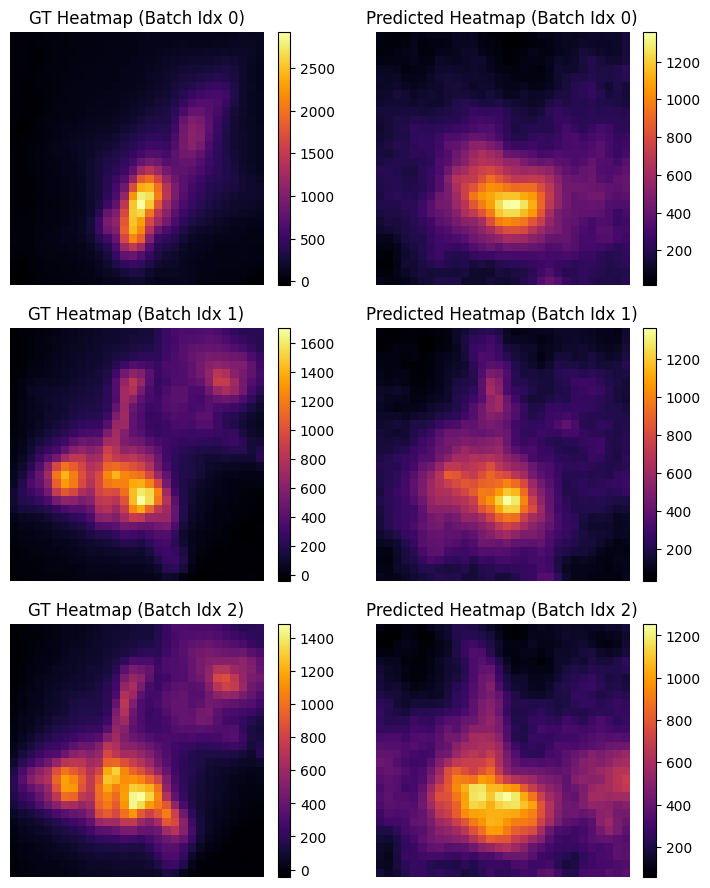

In [ ]:

# ---------------------------------------------------------
# 2. Spatial Reconstruction (2D 히트맵 공간 복원 비교)
# 첫 번째 배치를 가져와서 그 안에서 랜덤하게 num_samples 추출
# ---------------------------------------------------------
x_batch = sensor_ds.sensor_tensor[:32]
y_batch = sensor_ds.heatmap_tensor[:32]

x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

final_model.eval()
with torch.no_grad():
    pred_y_batch = final_model(x_batch)

# 배치 사이즈가 num_samples보다 작을 수 있으므로 예외 처리
actual_samples = min(3, x_batch.size(0))
indices = random.sample(range(x_batch.size(0)), actual_samples)
indices = [0, 1, 2]

fig, axes = plt.subplots(actual_samples, 2, figsize=(8, 3 * actual_samples))
if actual_samples == 1:
    axes = [axes]
    
for i, idx in enumerate(indices):
    # 텐서 -> Numpy 변환
    original_img = y_batch[idx].squeeze().cpu().numpy()
    reconstructed_img = pred_y_batch[idx].squeeze().cpu().numpy()
    
    # 외부 함수를 활용한 물리적 스케일 역산 
    original_real = _denormalise(original_img, global_min, global_max)
    reconstructed_real = _denormalise(reconstructed_img, global_min, global_max)

    # GT 히트맵 그리기
    im1 = axes[i][0].imshow(original_real, cmap='inferno', origin='upper')
    axes[i][0].set_title(f'GT Heatmap (Batch Idx {idx})')
    axes[i][0].axis('off')
    fig.colorbar(im1, ax=axes[i][0], fraction=0.046, pad=0.04)
    
    # 예측 히트맵 그리기 
    im2 = axes[i][1].imshow(reconstructed_real, cmap='inferno', origin='upper')
    axes[i][1].set_title(f'Predicted Heatmap (Batch Idx {idx})')
    axes[i][1].axis('off')
    fig.colorbar(im2, ax=axes[i][1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()